# Домашнее задание: Сбор данных и разметка: от формулировки задачи до крауда

В этом кейсе вы пройдёте путь **от постановки бизнеса** до **пайплайна гибридной разметки**:  
Постановка задачи → разметка zero shot промптом с помощью LLM → оценка качества → Улучшение качества промпта: few-shot, cot и другие способы → Оценка уверенности ответа




### Установка зависимостей

In [1]:
# !pip install -U --no-cache-dir --no-cache transformers accelerate kernels bitsandbytes great_tables

In [2]:
from pathlib import Path
import torch, json, random, re, pandas as pd, numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from sklearn.metrics import precision_recall_fscore_support
from tqdm.auto import tqdm
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)


Device: cuda


In [3]:
!nvidia-smi

Tue Apr 28 12:12:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   33C    P0             48W /  600W |       3MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 1. Постановка задачи


**Контекст (от лица бизнеса):**
Наша компания разрабатывает финтех-приложение с поддержкой пользователей через чат-бот.
Мы хотим автоматически определять тему запроса клиента (например: "блокировка карты", "потеря ПИН-кода", "перевыпуск карты", и т.д.), чтобы быстро направлять клиента к нужному решению. Требуется получить данные для задачи




**Описание задачи:**
> "Для каждого входящего текстового сообщения пользователя автоматически определить одну из тематик (например, balance, card_not_working, transfer, etc.)"

## 2. Требования и бизнес-метрики – 1 балл

Предложите не менее 2 бизнес-метрик, которые может хотеть оптимизировать бизнес относительно процесса разметки данных для данной задачи.


In [4]:
# ваш ответ тут

# ---- Ваш код здесь ----
print("""
Например,
- Среднее время маршрутизации обращения: время от получения сообщения до назначения корректной темы/очереди поддержки. 
  Улучшение метрики показывает, что клиент быстрее попадает к нужному специалисту.
- Доля обращений, обработанных автоматически без ручной классификации: процент сообщений, для которых LLM уверенно 
  назначила intent и не потребовалась проверка оператором. Метрика отражает снижение нагрузки на поддержку.
- Стоимость классификации одного обращения: суммарные затраты на LLM-инференс и ручную проверку, делённые на число 
  обработанных обращений. Метрика показывает экономический эффект от гибридной схемы LLM + human-in-the-loop.
  """)
# ---- Конец кода ----


Например,
- Среднее время маршрутизации обращения: время от получения сообщения до назначения корректной темы/очереди поддержки. 
  Улучшение метрики показывает, что клиент быстрее попадает к нужному специалисту.
- Доля обращений, обработанных автоматически без ручной классификации: процент сообщений, для которых LLM уверенно 
  назначила intent и не потребовалась проверка оператором. Метрика отражает снижение нагрузки на поддержку.
- Стоимость классификации одного обращения: суммарные затраты на LLM-инференс и ручную проверку, делённые на число 
  обработанных обращений. Метрика показывает экономический эффект от гибридной схемы LLM + human-in-the-loop.
  


## 3. Сведение к ML-задаче – 2 балла



Сведите бизнес-задачу к задаче машинного обучения, опишите входные данные и метки:

- **Тип задачи**: классификация
- **Объект**: текст сообщения клиента
- **Метки**: тема обращения

In [5]:
# ваш ответ тут

# ---- Ваш код здесь ----
print("""
- **Тип задачи**: multiclass классификация
- **Объект**: текст сообщения клиента
- **Метки**: тема обращения
""")
# ---- Конец кода ----


- **Тип задачи**: multiclass классификация
- **Объект**: текст сообщения клиента
- **Метки**: тема обращения



## 4. ML-метрики – 2 балла


Сформулируйте, какие метрики вы будете отслеживать в процессе сбора данных и получения разметки: как при помощи LLM, так и при помощи разметчиков в крауде

In [6]:
# ---- Ваш код здесь ----
print("""
- LLM разметчик: 
    - accuracy, 
    - precision, 
    - recall,
    - entropy, H(p) = − sum\\i(p\\i*log(p\\i))
    - macro-f1, 
- Разметчики в крауде: 
    - accuracy, 
    - macro-f1, 
    - Krippendorff’s alpha (для оценки согласованности между разметчиками), 
    - время разметки одного обращения (для оценки эффективности)

- Доля случаев, где нужен арбитр (когда разметчики в крауде не согласны между 
собой или с LLM) - насколько часто возникает необходимость в дополнительной 
проверке и может указывать на сложность задачи или качество разметки.
""")
# ---- Конец кода ----




- LLM разметчик: 
    - accuracy, 
    - precision, 
    - recall,
    - entropy, H(p) = − sum\i(p\i*log(p\i))
    - macro-f1, 
- Разметчики в крауде: 
    - accuracy, 
    - macro-f1, 
    - Krippendorff’s alpha (для оценки согласованности между разметчиками), 
    - время разметки одного обращения (для оценки эффективности)

- Доля случаев, где нужен арбитр (когда разметчики в крауде не согласны между 
собой или с LLM) - насколько часто возникает необходимость в дополнительной 
проверке и может указывать на сложность задачи или качество разметки.



## 5. Данные и бейзлайн разметка

### 5.1 Загрузка и первичный анализ датасета

Посмотрим данные: примеры из датасета (попробуем разметить сами хотя бы 10 примеров), все типы меток, размеры выборок, распределение

In [7]:
# !pip uninstall -y fsspec datasets
# !pip install fsspec==2024.2.0 datasets==2.18.0

from datasets import load_dataset, Dataset
import pandas as pd

ds = load_dataset('banking77')


# ---- Ваш код здесь ----
print("""
Считываем данные
""")
# ---- Конец кода ----

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(



Считываем данные



In [8]:
import polars as pl
import polars.selectors as cs
from great_tables import style, md


pl.Config(fmt_str_lengths=100)


df = pl.concat(
    [
        pl.from_pandas(dataset.to_pandas()).with_columns(pl.lit(split).alias("split")) # type: ignore
        for split, dataset in ds.items()
    ],
    how="vertical_relaxed",
)

labels = pl.DataFrame(
    {"intent": ds["test"].info.features["label"].names} # type: ignore
).with_row_index("label")

df = df.join(labels, on="label")

# Пример данных
(
    df.sample(5).style.tab_header(
        title="Пример размеченных данных",
        subtitle=f"выборок: {df['split'].n_unique()}, классов: {df['intent'].n_unique()}",
    )
)


GT(_tbl_data=shape: (5, 4)
┌───────────────────────────────────────────────┬───────┬───────┬──────────────────────────────────┐
│ text                                          ┆ label ┆ split ┆ intent                           │
│ ---                                           ┆ ---   ┆ ---   ┆ ---                              │
│ str                                           ┆ i64   ┆ str   ┆ str                              │
╞═══════════════════════════════════════════════╪═══════╪═══════╪══════════════════════════════════╡
│ How come my card payment has been declined?   ┆ 25    ┆ train ┆ declined_card_payment            │
│ I received the wrong exchange rate for an     ┆ 17    ┆ train ┆ card_payment_wrong_exchange_rate │
│ item i bought.                                ┆       ┆       ┆                                  │
│ I just received a new card, where do I go to  ┆ 13    ┆ train ┆ card_linking                     │
│ link it to my account?                        ┆       ┆       ┆                                  │
│ why must I prove ID                           ┆ 69    ┆ train ┆ verify_my_identity               │
│ How old do you have to be to get an account?  ┆ 1     ┆ test  ┆ age_limit                        │
└───────────────────────────────────────────────┴───────┴───────┴──────────────────────────────────┘, _body=<great_tables._gt_data.Body object at 0x7ec8f501fe30>, _boxhead=Boxhead([ColInfo(var='text', type=<ColInfoTypeEnum.default: 1>, column_label='text', column_align='left', column_width=None), ColInfo(var='label', type=<ColInfoTypeEnum.default: 1>, column_label='label', column_align='right', column_width=None), ColInfo(var='split', type=<ColInfoTypeEnum.default: 1>, column_label='split', column_align='left', column_width=None), ColInfo(var='intent', type=<ColInfoTypeEnum.default: 1>, column_label='intent', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7ec6e9429910>, _spanners=Spanners([]), _heading=Heading(title='Пример размеченных данных', subtitle='выборок: 2, классов: 77', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7ec6e94d0290>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7ec6e8bb63f0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7ec6e9428350>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), 

In [9]:
# Распределение классов по сплитам

df.group_by("split").agg(pl.col("label").n_unique())

split,label
str,u32
"""test""",77
"""train""",77


In [10]:
# Уникальные intent, содержащие не буквенные символы (например, вопросительные знаки)

df.filter(pl.col("intent").str.contains(r'\W'))['intent'].unique()

intent
str
"""reverted_card_payment?"""


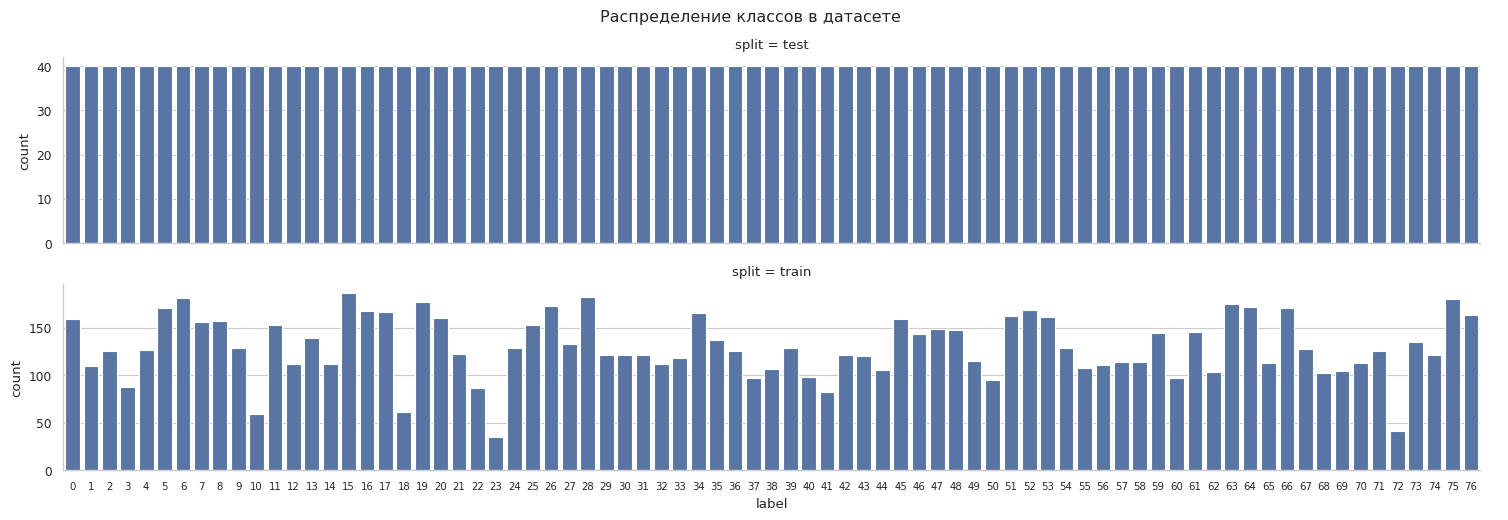

In [11]:
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme("paper", "whitegrid", rc={"xtick.labelsize": 7.25})


g = sns.catplot(
    data=df.select(["split", "label"]).to_pandas(),
    kind="count",
    row="split",
    row_order=["test", "train"],
    x="label",
    height=2.5,
    aspect=6,
    sharey=False,
)

plt.suptitle("Распределение классов в датасете", y=1.03)
plt.show()

In [12]:
# Оценим распределение длин текстов по классам и сплитам

df = df.with_columns(pl.col("text").str.split(" ").list.len().alias("text_length"))

_df = (
    df.group_by("split", "label", "intent")
    .agg(
        pl.min("text_length").cast(pl.Float64).alias("min"),
        pl.quantile("text_length", 0.25).alias("q1"),
        pl.mean("text_length").alias("mean"),
        pl.median("text_length").alias("median"),
        pl.quantile("text_length", 0.75).alias("q3"),
        pl.max("text_length").cast(pl.Float64).alias("max"),
        # pl.len().alias("count")
        )
    .sort("label", "split")
)

(
    _df
    .head(6)
    .style
    .fmt_number(columns=cs.float(), decimals=3)
    .tab_header(
        title="Распределение длин текстов по классам и сплитам",
        subtitle="сравнение статистик между train и test для каждого класса",
    )
    .show()
)

Распределение длин текстов по классам и сплитам 
 
 
 сравнение статистик между train и test для каждого класса 
 
 
 split 
 label 
 intent 
 min 
 q1 
 mean 
 median 
 q3 
 max 
 
 
 
 
 test 
 0 
 activate_my_card 
 3.000 
 7.000 
 9.275 
 9.000 
 11.000 
 19.000 
 
 
 train 
 0 
 activate_my_card 
 3.000 
 7.000 
 9.170 
 9.000 
 11.000 
 20.000 
 
 
 test 
 1 
 age_limit 
 5.000 
 8.000 
 10.000 
 10.500 
 12.000 
 15.000 
 
 
 train 
 1 
 age_limit 
 4.000 
 7.000 
 9.236 
 9.000 
 11.000 
 17.000 
 
 
 test 
 2 
 apple_pay_or_google_pay 
 4.000 
 8.000 
 10.500 
 9.500 
 13.000 
 25.000 
 
 
 train 
 2 
 apple_pay_or_google_pay 
 5.000 
 8.000 
 10.341 
 9.000 
 12.000 
 23.000

In [13]:
# Явно сравним распределение длин текстов между train и test внутри каждого класса
# и отберем классы, где устойчивые статистики заметно отличаются.

thr = 0.3  # аналитический порог
robust_stats = ["q1", "mean", "median", "q3"]

split_length_stats = (
    df.group_by("split", "label", "intent")
    .agg(
        pl.len().alias("n"),
        pl.min("text_length").cast(pl.Float64).alias("min"),
        pl.quantile("text_length", 0.25).alias("q1"),
        pl.mean("text_length").alias("mean"),
        pl.median("text_length").alias("median"),
        pl.quantile("text_length", 0.75).alias("q3"),
        pl.max("text_length").cast(pl.Float64).alias("max"),
    )
)

def split_table(split: str) -> pl.DataFrame:
    """Возвращает статистики длины текстов для указанного сплита."""
    return (
        split_length_stats
        .filter(pl.col("split") == split)
        .drop("split")
        .rename({
            "n": f"n_{split}",
            "min": f"min_{split}",
            "q1": f"q1_{split}",
            "mean": f"mean_{split}",
            "median": f"median_{split}",
            "q3": f"q3_{split}",
            "max": f"max_{split}",
        })
    )

train_stats = split_table("train")
test_stats = split_table("test")

length_shift = (
    train_stats
    .join(test_stats, on=["label", "intent"], how="inner")
    .with_columns([
        ((pl.col(f"{stat}_test") - pl.col(f"{stat}_train")) / pl.col(f"{stat}_train"))
        .alias(f"{stat}_rel_diff")
        for stat in robust_stats
    ])
    .with_columns(
        pl.max_horizontal([pl.col(f"{stat}_rel_diff").abs() for stat in robust_stats])
        .alias("max_abs_rel_diff"),
        (pl.col("mean_test") - pl.col("mean_train")).alias("mean_abs_diff"),
    )
    .with_columns(
        pl.when(pl.col("mean_abs_diff") > 0).then(pl.lit("test longer"))
        .when(pl.col("mean_abs_diff") < 0).then(pl.lit("train longer"))
        .otherwise(pl.lit("same mean"))
        .alias("direction")
    )
    .sort("max_abs_rel_diff", descending=True)
)

potential_split_shift = (
    length_shift
    .filter(pl.col("max_abs_rel_diff") >= thr)
    .select(
        "label",
        "intent",
        "direction",
        "n_train",
        "n_test",
        "mean_train",
        "mean_test",
        "mean_abs_diff",
        "mean_rel_diff",
        "median_train",
        "median_test",
        "median_rel_diff",
        "q1_rel_diff",
        "q3_rel_diff",
        "max_abs_rel_diff",
    )
)

diff_cols = ["mean_rel_diff", "median_rel_diff", "q1_rel_diff", "q3_rel_diff", "max_abs_rel_diff"]

(
    potential_split_shift
    .style
    .fmt_number(
        columns=["mean_train", "mean_test", "mean_abs_diff", "median_train", "median_test"],
        decimals=2,
    )
    .fmt_percent(columns=diff_cols, decimals=1)
    .tab_header(
        title="Классы с потенциальным сдвигом по длине текстов",
        subtitle=md(
            f"Отобраны классы, где |relative diff| >= {thr:.0%} "
            "хотя бы для одной из устойчивых статистик: q1, mean, median, q3"
        ),
    )
    .tab_spanner(label="train/test", columns=["n_train", "n_test"])
    .tab_spanner(
        label="length stats",
        columns=["mean_train", "mean_test", "mean_abs_diff", "median_train", "median_test"],
    )
    .tab_spanner(label="relative diff", columns=diff_cols)
    .data_color(
        columns="max_abs_rel_diff",
        palette=["white", "#ff0000"],
        domain=[thr, 1],
    )
)


GT(_tbl_data=shape: (12, 15)
┌───────┬────────────┬────────────┬─────────┬───┬────────────┬────────────┬────────────┬───────────┐
│ label ┆ intent     ┆ direction  ┆ n_train ┆ … ┆ median_rel ┆ q1_rel_dif ┆ q3_rel_dif ┆ max_abs_r │
│ ---   ┆ ---        ┆ ---        ┆ ---     ┆   ┆ _diff      ┆ f          ┆ f          ┆ el_diff   │
│ i64   ┆ str        ┆ str        ┆ u32     ┆   ┆ ---        ┆ ---        ┆ ---        ┆ ---       │
│       ┆            ┆            ┆         ┆   ┆ f64        ┆ f64        ┆ f64        ┆ f64       │
╞═══════╪════════════╪════════════╪═════════╪═══╪════════════╪════════════╪════════════╪═══════════╡
│ 47    ┆ pending_to ┆ test       ┆ 149     ┆ … ┆ 0.5        ┆ 0.0        ┆ 0.5        ┆ 0.5       │
│       ┆ p_up       ┆ longer     ┆         ┆   ┆            ┆            ┆            ┆           │
│ 59    ┆ top_up_fai ┆ train      ┆ 145     ┆ … ┆ -0.111111  ┆ -0.166667  ┆ -0.473684  ┆ 0.473684  │
│       ┆ led        ┆ longer     ┆         ┆   ┆            ┆            ┆            ┆           │
│ 35    ┆ failed_tra ┆ train      ┆ 137     ┆ … ┆ -0.3       ┆ -0.142857  ┆ -0.461538  ┆ 0.461538  │
│       ┆ nsfer      ┆ longer     ┆         ┆   ┆            ┆            ┆            ┆           │
│ 48    ┆ pending_tr ┆ train      ┆ 148     ┆ … ┆ -0.1       ┆ 0.0        ┆ -0.454545  ┆ 0.454545  │
│       ┆ ansfer     ┆ longer     ┆         ┆   ┆            ┆            ┆            ┆           │
│ 61    ┆ top_up_rev ┆ train      ┆ 146     ┆ … ┆ -0.1       ┆ 0.0        ┆ -0.428571  ┆ 0.428571  │
│       ┆ erted      ┆ longer     ┆         ┆   ┆            ┆            ┆            ┆           │
│ …     ┆ …          ┆ …          ┆ …       ┆ … ┆ …          ┆ …          ┆ …          ┆ …         │
│ 64    ┆ transfer_f ┆ train      ┆ 172     ┆ … ┆ -0.090909  ┆ -0.111111  ┆ -0.4       ┆ 0.4       │
│       ┆ ee_charged ┆ longer     ┆         ┆   ┆            ┆            ┆            ┆           │
│ 5     ┆ balance_no ┆ train      ┆ 171     ┆ … ┆ 0.0        ┆ 0.125      ┆ -0.380952  ┆ 0.380952  │
│       ┆ t_updated_ ┆ longer     ┆         ┆   ┆            ┆            ┆            ┆           │
│       ┆ after_bank ┆            ┆         ┆   ┆            ┆            ┆            ┆           │
│       ┆ _transfer  ┆            ┆         ┆   ┆            ┆            ┆            ┆           │
│ 72    ┆ virtual_ca ┆ test       ┆ 41      ┆ … ┆ 0.125      ┆ 0.333333   ┆ 0.2        ┆ 0.333333  │
│       ┆ rd_not_wor ┆ longer     ┆         ┆   ┆            ┆            ┆            ┆           │
│       ┆ king       ┆            ┆         ┆   ┆            ┆            ┆            ┆           │
│ 68    ┆ unable_to_ ┆ train      ┆ 102     ┆ … ┆ -0.125     ┆ 0.0        ┆ -0.111111  ┆ 0.322585  │
│       ┆ verify_ide ┆ longer     ┆         ┆   ┆            ┆            ┆            ┆           │
│       ┆ ntity      ┆            ┆         ┆   ┆            ┆            ┆            ┆           │
│ 45    ┆ pending_ca ┆ train      ┆ 159     ┆ … ┆ -0.181818  ┆ -0.125     ┆ -0.315789  ┆ 0.315789  │
│       ┆ rd_payment ┆ longer     ┆         ┆   ┆            ┆            ┆            ┆           │
└───────┴────────────┴────────────┴─────────┴───┴────────────┴────────────┴────────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x7ec6e2132030>, _boxhead=Boxhead([ColInfo(var='label', type=<ColInfoTypeEnum.default: 1>, column_label='label', column_align='right', column_width=None), ColInfo(var='intent', type=<ColInfoTypeEnum.default: 1>, column_label='intent', column_align='left', column_width=None), ColInfo(var='direction', type=<ColInfoTypeEnum.default: 1>, column_label='direction', column_align='left', column_width=None), ColInfo(var='n_train', type=<ColInfoTypeEnum.default: 1>, column_label='n_train', column_align='right', column_width=None), ColInfo(var='n_test', type=<ColInfoTypeEnum.default: 1>, column_label='n_test', column_align='right', column_width=None), ColInfo(var='mean_train', type=<ColInfoTypeEn

*Таблица показывает классы, где распределения длины текста заметно отличаются между `train` и `test`. Такие классы стоит проверить вручную: возможен сдвиг между сплитами, отдельные выбросы или неоднородные формулировки внутри intent. `min` и `max` не используются, потому что они слишком чувствительны к единичным выбросам.*

*Проверим, есть ли категории, для которых характерны короткие или длинные тексты. Сравним распределение длины внутри каждой категории с общим распределением и посчитаем `eta^2` — долю дисперсии длины текста, объясняемую категорией.*

In [14]:
global_length_stats = df.select(
    pl.len().alias("n"),
    pl.mean("text_length").alias("global_mean"),
    pl.median("text_length").alias("global_median"),
    pl.std("text_length").alias("global_std"),
    pl.quantile("text_length", 0.25).alias("global_q1"),
    pl.quantile("text_length", 0.75).alias("global_q3"),
)

global_mean = global_length_stats["global_mean"][0]
global_median = global_length_stats["global_median"][0]
global_std = global_length_stats["global_std"][0]

label_length_stats = (
    df.group_by("label", "intent")
    .agg(
        pl.len().alias("n"),
        pl.mean("text_length").alias("mean_len"),
        pl.median("text_length").alias("median_len"),
        pl.quantile("text_length", 0.25).alias("q1"),
        pl.quantile("text_length", 0.75).alias("q3"),
        pl.min("text_length").alias("min_len"),
        pl.max("text_length").alias("max_len"),
    )
    .with_columns(
        (pl.col("mean_len") - global_mean).alias("mean_delta"),
        ((pl.col("mean_len") - global_mean) / global_std).alias("mean_z"),
        (pl.col("median_len") - global_median).alias("median_delta"),
    )
)

ss_between = label_length_stats.select(
    (pl.col("n") * (pl.col("mean_len") - global_mean) ** 2).sum()
).item()
ss_total = df.select(((pl.col("text_length") - global_mean) ** 2).sum()).item()
eta_squared = ss_between / ss_total

length_extremes = pl.concat(
    [
        label_length_stats.sort("mean_delta").head(10)
        .with_columns(pl.lit("short").alias("length_group")),
        label_length_stats.sort("mean_delta", descending=True).head(10)
        .with_columns(pl.lit("long").alias("length_group")),
    ]
).select(
    "length_group",
    "label",
    "intent",
    "n",
    "mean_len",
    "median_len",
    "q1",
    "q3",
    "mean_delta",
    "median_delta",
    "mean_z",
)

print(f"Общая средняя длина: {global_mean:.2f} слов")
print(f"Общая медианная длина: {global_median:.0f} слов")
print(f"eta^2(label -> text_length): {eta_squared:.3f}")

(
    length_extremes
    .sort("mean_delta", descending=False)
    .style
    .fmt_number(columns=cs.float(), decimals=2)
    .tab_header(
        title="Категории с самыми короткими и длинными текстами",
        subtitle="mean_delta - отклонение средней длины категории от общей средней длины",
    )
    .data_color(
        columns="mean_z",
        palette="RdBu",
        reverse=True,
        domain=[
            -length_extremes["mean_z"].abs().max(),  # type: ignore
            length_extremes["mean_z"].abs().max()
            ],
    )
)


Общая средняя длина: 11.77 слов
Общая медианная длина: 10 слов
eta^2(label -> text_length): 0.130


GT(_tbl_data=shape: (20, 11)
┌──────────────┬───────┬──────────────────┬─────┬───┬──────┬────────────┬──────────────┬───────────┐
│ length_group ┆ label ┆ intent           ┆ n   ┆ … ┆ q3   ┆ mean_delta ┆ median_delta ┆ mean_z    │
│ ---          ┆ ---   ┆ ---              ┆ --- ┆   ┆ ---  ┆ ---        ┆ ---          ┆ ---       │
│ str          ┆ i64   ┆ str              ┆ u32 ┆   ┆ f64  ┆ f64        ┆ f64          ┆ f64       │
╞══════════════╪═══════╪══════════════════╪═════╪═══╪══════╪════════════╪══════════════╪═══════════╡
│ short        ┆ 10    ┆ card_acceptance  ┆ 99  ┆ … ┆ 9.0  ┆ -4.33681   ┆ -2.0         ┆ -0.560805 │
│ short        ┆ 38    ┆ get_physical_car ┆ 146 ┆ … ┆ 9.0  ┆ -4.243756  ┆ -3.0         ┆ -0.548772 │
│              ┆       ┆ d                ┆     ┆   ┆      ┆            ┆              ┆           │
│ short        ┆ 3     ┆ atm_support      ┆ 127 ┆ … ┆ 9.0  ┆ -4.149106  ┆ -3.0         ┆ -0.536532 │
│ short        ┆ 32    ┆ exchange_rate    ┆ 152 ┆ … ┆ 9.0  ┆ -4.093522  ┆ -3.0         ┆ -0.529344 │
│ short        ┆ 60    ┆ top_up_limits    ┆ 137 ┆ … ┆ 9.0  ┆ -4.063124  ┆ -3.0         ┆ -0.525414 │
│ …            ┆ …     ┆ …                ┆ …   ┆ … ┆ …    ┆ …          ┆ …            ┆ …         │
│ long         ┆ 28    ┆ direct_debit_pay ┆ 222 ┆ … ┆ 16.0 ┆ 4.116234   ┆ 2.0          ┆ 0.532281  │
│              ┆       ┆ ment_not_recogni ┆     ┆   ┆      ┆            ┆              ┆           │
│              ┆       ┆ sed              ┆     ┆   ┆      ┆            ┆              ┆           │
│ long         ┆ 63    ┆ transaction_char ┆ 215 ┆ … ┆ 19.0 ┆ 4.307916   ┆ 0.0          ┆ 0.557068  │
│              ┆       ┆ ged_twice        ┆     ┆   ┆      ┆            ┆              ┆           │
│ long         ┆ 46    ┆ pending_cash_wit ┆ 183 ┆ … ┆ 20.0 ┆ 4.573109   ┆ 1.0          ┆ 0.591361  │
│              ┆       ┆ hdrawal          ┆     ┆   ┆      ┆            ┆              ┆           │
│ long         ┆ 64    ┆ transfer_fee_cha ┆ 212 ┆ … ┆ 19.0 ┆ 5.242998   ┆ 1.0          ┆ 0.677986  │
│              ┆       ┆ rged             ┆     ┆   ┆      ┆            ┆              ┆           │
│ long         ┆ 66    ┆ transfer_not_rec ┆ 211 ┆ … ┆ 25.0 ┆ 5.480031   ┆ 1.0          ┆ 0.708638  │
│              ┆       ┆ eived_by_recipie ┆     ┆   ┆      ┆            ┆              ┆           │
│              ┆       ┆ nt               ┆     ┆   ┆      ┆            ┆              ┆           │
└──────────────┴───────┴──────────────────┴─────┴───┴──────┴────────────┴──────────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x7ec6d41027e0>, _boxhead=Boxhead([ColInfo(var='length_group', type=<ColInfoTypeEnum.default: 1>, column_label='length_group', column_align='left', column_width=None), ColInfo(var='label', type=<ColInfoTypeEnum.default: 1>, column_label='label', column_align='right', column_width=None), ColInfo(var='intent', type=<ColInfoTypeEnum.default: 1>, column_label='intent', column_align='left', column_width=None), ColInfo(var='n', type=<ColInfoTypeEnum.default: 1>, column_label='n', column_align='right', column_width=None), ColInfo(var='mean_len', type=<ColInfoTypeEnum.default: 1>, column_label='mean_len', column_align='right', column_width=None), ColInfo(var='median_len', type=<ColInfoTypeEnum.default: 1>, column_label='median_len', column_align='right', column_width=None), ColInfo(var='q1', type=<ColInfoTypeEnum.default: 1>, column_label='q1', column_align='right', column_width=None), ColInfo(var='q3', type=<ColInfoTypeEnum.default: 1>, column_label='q3', column_align='right', column_width=None), ColInfo(var='mean_delta', type=<ColInfoTypeEnum.default: 1>, column_label='mean_delta', column_align='right', column_width=None), ColInfo(var='median_delta', type=<ColInfoTypeEnum.default: 1>, column_label='median_delta', column_align='right', column_width=None), ColInfo(var='mean_z', type=<ColInfoTypeEnum.default: 1>, column_label='mean_z', column_align='right', column_width=None)]), _stub=<g

*Связь между категорией и длиной текста есть, но она умеренная: `eta^2 ≈ 0.13`, то есть категория объясняет около 13% дисперсии `text_length`. В среднем по датасету текст содержит около 11.8 слов, медиана — 10 слов.*

*Короткие тексты характерны для `card_acceptance`, `get_physical_card`, `atm_support`, `exchange_rate`, `top_up_limits`, `passcode_forgotten`, `order_physical_card`.  
Длинные тексты чаще встречаются в категориях `transfer_not_received_by_recipient`, `transfer_fee_charged`, `pending_cash_withdrawal`, `transaction_charged_twice`, `direct_debit_payment_not_recognised`, `Refund_not_showing_up`, `wrong_exchange_rate_for_cash_withdrawal`.*

In [15]:
# Дублей текстов нет

df.n_unique("text") == df.height

True

### 5.2 Бейзлайн LLM разметка (7 баллов)

В этом пункте нужно получить бейзлайн разметку с помощью open source LLM и простого короткого промпта.

Для упрощения тут у нас уже есть golden set разметка (в случае если не было бы, то действовали как указано в лекции, или бы размечали для начала сами хотя бы 50-100 примеров), на которой мы можем проверять качество

В качестве LLM можно также взять https://huggingface.co/IlyaGusev/saiga_yandexgpt_8b . Либо можно заменить на любую open-source (например "Qwen/Qwen3-8B", "meta-llama/Meta-Llama-3-8B-Instruct", "mistralai/Mistral-7B-Instruct-v0.2", и т.д.)

In [16]:
# !pip install -U accelerate bitsandbytes transformers

In [17]:
# # ---- Ваш код здесь ----
# print("""
#     Загружаем выбранную LLM
#     В некоторых случаях может понадобиться !pip install -U accelerate bitsandbytes transformers
# """)

# import openai
# import os
# from dotenv import load_dotenv


# load_dotenv()

# FOLDER_ID=os.environ["FOLDER_ID"]
# API_KEY=os.environ["API_KEY"]
# # MODEL = "yandexgpt-5-lite/latest"
# # MODEL = "yandexgpt-5.1/latest"
# MODEL = "qwen3.5-35b-a3b-fp8/latest"

# client = openai.OpenAI(
#     api_key=API_KEY,
#     project=FOLDER_ID,
#     base_url="https://ai.api.cloud.yandex.net/v1"
# )

# очень удобно, но не дешево :((  пошли в колаб

# # ---- Конец кода ----

In [18]:
model_id = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Формируем простой короткий промпт, в котором укажем  все категории меток для разметки, и потребуем выход в нужном формате json {"label": str}, для которого напишем функцию парсинга



In [19]:
# ---- Ваш код здесь ----
label_names = labels["intent"].to_list()
label_list = "\n".join(f"- {label}" for label in label_names)

prompt_template = f"""
Ты классифицируешь короткие обращения клиентов банка по одной теме обращения.

Правила:
1. Выбери ровно одну категорию из списка ниже.
2. Верни название категории точно как в списке: с тем же регистром, подчёркиваниями и знаками пунктуации.
3. Не придумывай новые категории. Если запрос неоднозначный, выбери ближайшую подходящую категорию.
4. Не рассуждай.
5. Не объясняй выбор.
6. Не выводи chain-of-thought, reasoning, analysis, комментарии или markdown.
7. ОТВЕТ ДОЛЖЕН БЫТЬ ТОЛЬКО ВАЛИДНЫМ JSON без markdown, пояснений и дополнительного текста.

Формат ответа:
{{"label": "category_name"}}

Список категорий:
{label_list}
""".strip()
# ---- Конец кода ----


Делаем разметку 10-20 примеров, пишем функцию парсинга ответа (считаем метрику в скольких ответах нарушения следования формату), смотрим ответы

In [20]:
# Функция разметки вместе с промптом,

# ---- Ваш код здесь ----

import ast
from typing import Any


# print("""
#     прокачиваем в цикле выбранную LLM для разметки данных через функцию annotate, добавляем разметку в исходный датасет и сохраняем в файл
# """)


def get_label_from_llm(
    input_task: str,
    max_new_tokens=32,
    do_sample=False,
    temperature=None,
    top_p=None,
    top_k=None,
) -> str:
    """Генерирует ответ LLM для одного клиентского обращения."""
    
    messages = [
        {"role": "system", "content": prompt_template},
        {"role": "user", "content": input_task},
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated_ids = output_ids[0][inputs.input_ids.shape[-1] :]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


def parse_response(response) -> dict[str, Any]:
    """Извлекает предсказанную метку из сырого ответа LLM."""
    
    raw_response = response
    cleaned = re.sub(
        r"^```(?:json)?\s*|\s*```$",
        "",
        raw_response,
        flags=re.IGNORECASE | re.DOTALL,
    ).strip()

    json_match = re.search(r"\{.*?\}", cleaned, flags=re.DOTALL)

    if not json_match:
        candidate = cleaned.strip().strip('"').strip("'")
        if candidate in label_names:
            return {"label": candidate, "corrupted": 1, "raw_response": raw_response}
        return {"label": None, "corrupted": 1, "raw_response": raw_response}

    json_text = json_match.group(0)

    try:
        parsed = json.loads(json_text)
    except json.JSONDecodeError:
        try:
            parsed = ast.literal_eval(json_text)
        except (SyntaxError, ValueError):
            return {"label": None, "corrupted": 1, "raw_response": raw_response}

    if isinstance(parsed, list) and len(parsed) == 1:
        parsed = parsed[0]

    if not isinstance(parsed, dict):
        return {"label": None, "corrupted": 1, "raw_response": raw_response}

    label = parsed.get("label")
    if isinstance(label, str):
        label = label.strip()

    corrupted = int(not isinstance(label, str) or label not in label_names)
    return {"label": label, "corrupted": corrupted, "raw_response": raw_response}


def annotate(
    data: pl.DataFrame,
    text_col: str = "text",
    max_new_tokens=32,
    do_sample=False,
    temperature=None,
    top_p=None,
    top_k=None,
) -> pl.DataFrame:
    """
    Размечает строки DataFrame с помощью LLM.
    Для каждого текста из text_col получает ответ модели и парсит его.
    """
    parsed_responses = []

    for text in tqdm(data[text_col].to_list()):
        try:
            parsed = parse_response(
                get_label_from_llm(
                    text,
                    max_new_tokens=max_new_tokens,
                    do_sample=do_sample,
                    temperature=temperature,
                    top_p=top_p,
                    top_k=top_k,
                )
            )
        except Exception as exc:
            parsed = {
                "label": None,
                "corrupted": 1,
                "raw_response": f"ERROR: {type(exc).__name__}: {exc}",
            }
        parsed_responses.append(parsed)

    return data.with_columns(
        pl.Series(
            "pred_label", [row.get("label") for row in parsed_responses], dtype=pl.Utf8
        ),
        pl.Series(
            "corrupted",
            [row.get("corrupted", 1) for row in parsed_responses],
            dtype=pl.Int64,
        ),
        pl.Series(
            "raw_response",
            [row.get("raw_response") for row in parsed_responses],
            dtype=pl.Utf8,
        ),
    )


# ---- Конец кода ----


In [21]:
# Тестируем функцию разметки на первых 10 строках датасета

annotate(df[:10])

  0%|          | 0/10 [00:00<?, ?it/s]

text,label,split,intent,text_length,pred_label,corrupted,raw_response
str,i64,str,str,u32,str,i64,str
"""I am still waiting on my card?""",11,"""train""","""card_arrival""",7,"""card_delivery_estimate""",0,"""{""label"": ""card_delivery_estimate""}"""
"""What can I do if my card still hasn't arrived after 2 weeks?""",11,"""train""","""card_arrival""",13,"""card_delivery_estimate""",0,"""{""label"": ""card_delivery_estimate""}"""
"""I have been waiting over a week. Is the card still coming?""",11,"""train""","""card_arrival""",12,"""card_delivery_estimate""",0,"""{""label"": ""card_delivery_estimate""}"""
"""Can I track my card while it is in the process of delivery?""",11,"""train""","""card_arrival""",13,"""card_delivery_estimate""",0,"""{""label"": ""card_delivery_estimate""}"""
"""How do I know if I will get my card, or if it is lost?""",11,"""train""","""card_arrival""",15,"""lost_or_stolen_card""",0,"""{""label"": ""lost_or_stolen_card""}"""
"""When did you send me my new card?""",11,"""train""","""card_arrival""",8,"""card_arrival""",0,"""{""label"": ""card_arrival""}"""
"""Do you have info about the card on delivery?""",11,"""train""","""card_arrival""",9,"""card_delivery_estimate""",0,"""{""label"": ""card_delivery_estimate""}"""
"""What do I do if I still have not received my new card?""",11,"""train""","""card_arrival""",13,"""getting_spare_card""",1,"""getting_spare_card"""
"""Does the package with my card have tracking?""",11,"""train""","""card_arrival""",8,"""card_arrival""",0,"""{""label"": ""card_arrival""}"""


### 5.3 Оценка качества (2 балла)

Оцениваем качество разметки на тестовом датасет (либо на семпле из тестового датасета)



In [22]:
# ---- Ваш код здесь ----


def calculate_llm_metrics(
    data: pl.DataFrame,
    true_col: str = "intent",
    pred_col: str = "pred_label",
    label_names: list[str] | None = None,
) -> pl.DataFrame:
    """Считает агрегированные метрики качества LLM-разметки.

    Невалидные предсказания заменяются служебной меткой, после чего функция
    возвращает одну строку с accuracy, entropy, macro_f1, precision и recall.
    """
    if label_names is None:
        valid_labels = (
            data.select(pl.col(true_col).cast(pl.Utf8).drop_nulls().unique())
            .to_series()
            .to_list()
        )
    else:
        valid_labels = label_names

    scored = data.select(
        pl.col(true_col).cast(pl.Utf8).alias("true_label"),
        pl.when(pl.col(pred_col).cast(pl.Utf8, strict=False).is_in(valid_labels))
        .then(pl.col(pred_col).cast(pl.Utf8, strict=False))
        .otherwise(pl.lit("__invalid_label__"))
        .alias("pred_label"),
    )

    accuracy = scored.select(
        (pl.col("true_label") == pl.col("pred_label")).mean().alias("accuracy")
    )

    entropy = (
        scored.filter(pl.col("pred_label") != "__invalid_label__")
        .group_by("pred_label")
        .len()
        .with_columns((pl.col("len") / pl.col("len").sum()).alias("p"))
        .select((-(pl.col("p") * pl.col("p").log()).sum()).alias("entropy"))
    )

    labels_for_eval = (
        scored.select(pl.col("true_label").drop_nulls().unique()).to_series().to_list()
    )
    prec, rec, macro_f1_value, _ = precision_recall_fscore_support(
        scored["true_label"].to_list(),
        scored["pred_label"].to_list(),
        labels=labels_for_eval,
        average="macro",
        zero_division=0,
    )
    precision = pl.DataFrame({"precision": [float(prec)]})
    recall = pl.DataFrame({"recall": [float(rec)]})
    macro_f1 = pl.DataFrame({"macro_f1": [float(macro_f1_value)]})

    return (
        accuracy.join(entropy, how="cross")
        .join(macro_f1, how="cross")
        .join(precision, how="cross")
        .join(recall, how="cross")
    )


# ---- Конец кода ----

In [23]:
# Разметка

test_df = (
    df
    .filter(pl.col("split") == "test")
    .group_by("label", "intent")
    .agg(
        pl.col('text').sample(5, seed=20260426)
    )
    .explode("text")
)

# Если разметку уже делали, то загружаем ее из файла для эконимии ресурсов
markup_path = Path("test_llm_markup.parquet")
if markup_path.exists():
    test_llm_markup = pl.read_parquet(markup_path)
else:
    test_llm_markup = annotate(test_df)
    test_llm_markup.write_parquet("test_llm_markup.parquet")

  0%|          | 0/385 [00:00<?, ?it/s]

In [24]:
if "test_llm_markup" not in globals():
    test_llm_markup = pl.read_parquet("test_llm_markup.parquet")

calculate_llm_metrics(test_llm_markup)

accuracy,entropy,macro_f1,precision,recall
f64,f64,f64,f64,f64
0.592208,4.033298,0.557172,0.595093,0.592208


## 6. Улучшение качества промпта

### 6.1 few shot prompt (4 баллов)

Добавим в промпт few-shot примеры (важно, чтобы не было data leak  c тестом): помогает исправлять поведение модели, когда описание в инструкции не справляется + модель лучше следует форматам

In [25]:
# ---- Ваш код здесь ----

torch.cuda.empty_cache()

if "zero_shot_prompt_template" not in globals():
    zero_shot_prompt_template = prompt_template

# Few-shot примеры берем только из train, чтобы не подглядывать в тест.
# Подбираем близкие и часто путаемые банковские интенты: карты, снятие наличных,
# переводы, top-up и спорные/неопознанные операции.
few_shot_intents = [
    "card_arrival",
    "card_delivery_estimate",
    "card_payment_not_recognised",
    "cash_withdrawal_charge",
    "cash_withdrawal_not_recognised",
    "declined_cash_withdrawal",
    "pending_cash_withdrawal",
    "failed_transfer",
    "pending_transfer",
    "transfer_fee_charged",
    "transfer_not_received_by_recipient",
    "pending_top_up",
    "top_up_failed",
    "top_up_reverted",
    "compromised_card",
    "transaction_charged_twice",
]
few_shot_intents = [intent for intent in few_shot_intents if intent in label_names]

few_shot_source = (
    df
    if "text_length" in df.columns
    else df.with_columns(pl.col("text").str.split(" ").list.len().alias("text_length"))
)

# Примеры берем из train
few_shot_examples = (
    few_shot_source
    .filter((pl.col("split") == "train") & pl.col("intent").is_in(few_shot_intents))
    .sort(["intent", "text_length"])
    .group_by("intent", maintain_order=True)
    .agg(
        pl.col("text").first().alias("text"),
        pl.col("label").first().alias("label_id"),
    )
    .sort("intent")
)


def format_few_shot_examples(examples: pl.DataFrame) -> str:
    """Формирует текстовый блок few-shot примеров для промпта.

    Ожидает строки с колонками text и intent, нумерует примеры и сериализует
    эталонный ответ в JSON-формате {"label": intent}.
    """
    chunks = []
    for idx, row in enumerate(examples.iter_rows(named=True), start=1):
        chunks.append(
            f"Пример {idx}:\n"
            f"Текст: {json.dumps(row['text'], ensure_ascii=False)}\n"
            f"Ответ: {json.dumps({'label': row['intent']}, ensure_ascii=False)}"
        )
    return "\n\n".join(chunks)


few_shot_examples_text = format_few_shot_examples(few_shot_examples)

few_shot_prompt_template = f"""
Ты классифицируешь короткие обращения клиентов банка по одной теме обращения.

Правила:
1. Выбери ровно одну категорию из списка ниже.
2. Верни название категории точно как в списке: с тем же регистром, подчёркиваниями и знаками пунктуации.
3. Не придумывай новые категории. Если запрос неоднозначный, выбери ближайшую подходящую категорию.
4. Используй few-shot примеры ниже как ориентир для различения похожих категорий.
5. Не рассуждай и не объясняй выбор.
6. Не выводи chain-of-thought, reasoning, analysis, комментарии или markdown.
7. ОТВЕТ ДОЛЖЕН БЫТЬ ТОЛЬКО ВАЛИДНЫМ JSON без markdown, пояснений и дополнительного текста.

Формат ответа:
{{"label": "category_name"}}

Few-shot примеры из train:
{few_shot_examples_text}

Список категорий:
{label_list}
""".strip()


prompt_template = few_shot_prompt_template

# Если разметку уже делали, то загружаем ее из файла для эконимии ресурсов
few_shot_markup_path = Path("test_llm_markup_few_shot.parquet")
if few_shot_markup_path.exists():
    test_llm_markup_few_shot = pl.read_parquet(few_shot_markup_path)
else:
    test_llm_markup_few_shot = annotate(test_df)
    test_llm_markup_few_shot.write_parquet(few_shot_markup_path)

metrics_compare = pl.concat(
    [
        calculate_llm_metrics(test_llm_markup).with_columns(pl.lit("zero_shot").alias("prompt")),
        calculate_llm_metrics(test_llm_markup_few_shot).with_columns(pl.lit("few_shot").alias("prompt")),
    ],
    how="vertical",
).select("prompt", "accuracy", "macro_f1", "precision", "recall", "entropy")

metrics_compare

# ---- Конец кода ----

  0%|          | 0/385 [00:00<?, ?it/s]

prompt,accuracy,macro_f1,precision,recall,entropy
str,f64,f64,f64,f64,f64
"""zero_shot""",0.592208,0.557172,0.595093,0.592208,4.033298
"""few_shot""",0.623377,0.602824,0.666651,0.623377,4.100281


### 6.2 chain-of-thoughts (3 балла)

Добавляем chain-of-thought/rationale в промпт: просим модель вернуть короткое обоснование вместе с меткой. Это дает интерпретируемость ошибок и иногда помогает модели внимательнее различать похожие интенты.

JSON на выходе теперь формата:
`{"reasoning": "why_this_class", "label": "one_of_the_categories"}`

In [26]:
# ---- Ваш код здесь ----

torch.cuda.empty_cache()

from typing import Any


if "zero_shot_prompt_template" not in globals():
    zero_shot_prompt_template = prompt_template

if "few_shot_examples" not in globals():
    few_shot_source = (
        df
        if "text_length" in df.columns
        else df.with_columns(
            pl.col("text").str.split(" ").list.len().alias("text_length")
        )
    )
    few_shot_examples = (
        few_shot_source.filter(pl.col("split") == "train")
        .sort(["intent", "text_length"])
        .group_by("intent", maintain_order=True)
        .agg(pl.col("text").first().alias("text"))
        .sort("intent")
        .head(16)
    )


def format_cot_examples(examples: pl.DataFrame) -> str:
    """Формирует few-shot примеры с коротким reasoning для CoT-промпта.

    Для каждой строки с text и intent создает пример ответа с полями reasoning
    и label, затем объединяет примеры в один текстовый блок.
    """
    chunks = []
    for idx, row in enumerate(examples.iter_rows(named=True), start=1):
        intent = row["intent"]
        reasoning = (
            f"В тексте есть признаки темы {intent}: формулировка обращения "
            "напрямую совпадает с этой банковской проблемой."
        )
        chunks.append(
            f"Пример {idx}:\n"
            f"Текст: {json.dumps(row['text'], ensure_ascii=False)}\n"
            f"Ответ: {json.dumps({'reasoning': reasoning, 'label': intent}, ensure_ascii=False)}"
        )
    return "\n\n".join(chunks)


cot_examples_text = format_cot_examples(few_shot_examples)

cot_prompt_template = f"""
Ты классифицируешь короткие обращения клиентов банка по одной теме обращения.

Правила:
1. Выбери ровно одну категорию из списка ниже.
2. Верни название категории точно как в списке: с тем же регистром, подчёркиваниями и знаками пунктуации.
3. Не придумывай новые категории. Если запрос неоднозначный, выбери ближайшую подходящую категорию.
4. Сначала в поле reasoning дай короткое обоснование выбора: одно предложение про ключевые слова или смысл обращения.
5. Используй few-shot примеры ниже как ориентир для различения похожих категорий.
6. Не выводи markdown, комментарии или дополнительный текст вне JSON.
7. ОТВЕТ ДОЛЖЕН БЫТЬ ТОЛЬКО ВАЛИДНЫМ JSON.

Формат ответа:
{{"reasoning": "short_reason", "label": "category_name"}}

Few-shot примеры из train:
{cot_examples_text}

Список категорий:
{label_list}
""".strip()


def parse_response_with_reasoning(response: str) -> dict[str, Any]:
    """Извлекает label и reasoning из ответа LLM.

    Удаляет markdown-обертку и think-блоки, парсит JSON или Python literal,
    принимает reasoning из альтернативных полей и валидирует label по label_names.
    """
    raw_response = str(response)
    cleaned = re.sub(
        r"^```(?:json)?\s*|\s*```$",
        "",
        raw_response,
        flags=re.IGNORECASE | re.DOTALL,
    ).strip()
    cleaned = re.sub(
        r"<think>.*?</think>", "", cleaned, flags=re.IGNORECASE | re.DOTALL
    ).strip()

    json_match = re.search(r"\{.*\}", cleaned, flags=re.DOTALL)
    if not json_match:
        candidate = cleaned.strip().strip('"').strip("'")
        if candidate in label_names:
            return {
                "label": candidate,
                "reasoning": None,
                "corrupted": 1,
                "raw_response": raw_response,
            }
        return {
            "label": None,
            "reasoning": None,
            "corrupted": 1,
            "raw_response": raw_response,
        }

    json_text = json_match.group(0)
    try:
        parsed = json.loads(json_text)
    except json.JSONDecodeError:
        try:
            parsed = ast.literal_eval(json_text)
        except (SyntaxError, ValueError):
            return {
                "label": None,
                "reasoning": None,
                "corrupted": 1,
                "raw_response": raw_response,
            }

    if isinstance(parsed, list) and len(parsed) == 1:
        parsed = parsed[0]

    if not isinstance(parsed, dict):
        return {
            "label": None,
            "reasoning": None,
            "corrupted": 1,
            "raw_response": raw_response,
        }

    label = parsed.get("label")
    if isinstance(label, str):
        label = label.strip()

    reasoning = parsed.get("reasoning") or parsed.get("rationale") or parsed.get("why")
    if isinstance(reasoning, str):
        reasoning = reasoning.strip()
    else:
        reasoning = None

    corrupted = int(not isinstance(label, str) or label not in label_names)
    return {
        "label": label,
        "reasoning": reasoning,
        "corrupted": corrupted,
        "raw_response": raw_response,
    }


def annotate_with_reasoning(
    data: pl.DataFrame,
    text_col: str = "text",
    max_new_tokens=100,
    do_sample=False,
    temperature=None,
    top_p=None,
    top_k=None,
) -> pl.DataFrame:
    """Размечает DataFrame и сохраняет краткое объяснение ответа модели."""
    
    parsed_responses = []

    for text in tqdm(data[text_col].to_list()):
        try:
            parsed = parse_response_with_reasoning(
                get_label_from_llm(
                    text,
                    max_new_tokens=max_new_tokens,
                    do_sample=do_sample,
                    temperature=temperature,
                    top_p=top_p,
                    top_k=top_k,
                )
            )
        except Exception as exc:
            parsed = {
                "label": None,
                "reasoning": None,
                "corrupted": 1,
                "raw_response": f"ERROR: {type(exc).__name__}: {exc}",
            }
        parsed_responses.append(parsed)

    return data.with_columns(
        pl.Series(
            "pred_label", [row.get("label") for row in parsed_responses], dtype=pl.Utf8
        ),
        pl.Series(
            "reasoning",
            [row.get("reasoning") for row in parsed_responses],
            dtype=pl.Utf8,
        ),
        pl.Series(
            "corrupted",
            [row.get("corrupted", 1) for row in parsed_responses],
            dtype=pl.Int64,
        ),
        pl.Series(
            "raw_response",
            [row.get("raw_response") for row in parsed_responses],
            dtype=pl.Utf8,
        ),
    )


prompt_template = cot_prompt_template

# Если разметку уже делали, то загружаем ее из файла для эконимии ресурсов
cot_markup_path = Path("test_llm_markup_cot.parquet")
if cot_markup_path.exists():
    test_llm_markup_cot = pl.read_parquet(cot_markup_path)
else:
    test_llm_markup_cot = annotate_with_reasoning(test_df)
    test_llm_markup_cot.write_parquet(cot_markup_path)

if "test_llm_markup" not in globals():
    test_llm_markup = pl.read_parquet("test_llm_markup.parquet")

if "test_llm_markup_few_shot" not in globals():
    test_llm_markup_few_shot = pl.read_parquet("test_llm_markup_few_shot.parquet")

metrics_compare_cot = pl.concat(
    [
        calculate_llm_metrics(test_llm_markup).with_columns(
            pl.lit("zero_shot").alias("prompt")
        ),
        calculate_llm_metrics(test_llm_markup_few_shot).with_columns(
            pl.lit("few_shot").alias("prompt")
        ),
        calculate_llm_metrics(test_llm_markup_cot).with_columns(
            pl.lit("few_shot_cot").alias("prompt")
        ),
    ],
    how="vertical",
).select("prompt", "accuracy", "macro_f1", "precision", "recall", "entropy")

cot_examples_preview = test_llm_markup_cot.select(
    "text",
    "intent",
    "pred_label",
    "reasoning",
    "corrupted",
).head(5)

display(cot_examples_preview)

metrics_compare_cot

# ---- Конец кода ----

  0%|          | 0/385 [00:00<?, ?it/s]

text,intent,pred_label,reasoning,corrupted
str,str,str,str,i64
"""How do I unblock my pin after entering it wrong too many times?""","""pin_blocked""","""pin_blocked""","""В тексте есть признаки темы pin_blocked: формулировка обращения напрямую совпадает с этой банковской…",0
"""I entered the wrong pin too many times and now I am blocked. Help me unblock!""","""pin_blocked""","""pin_blocked""","""В тексте есть признаки темы pin_blocked: формулировка обращения напрямую совпадает с этой банковской…",0
"""How can I unlock my pin from too many tries?""","""pin_blocked""","""pin_blocked""","""В тексте есть признаки темы pin_blocked: вопрос о блокировке пин-кода.""",0
"""How can I unblock a blocked pin number for my account?""","""pin_blocked""","""pin_blocked""","""В тексте есть признаки темы pin_blocked: формулировка обращения напрямую совпадает с этой банковской…",0
"""When I put the wrong pin too much, I got blocked, so can you help me unblock my pin""","""pin_blocked""","""pin_blocked""","""В тексте есть признаки темы pin_blocked: формулировка обращения напрямую совпадает с этой банковской…",0


prompt,accuracy,macro_f1,precision,recall,entropy
str,f64,f64,f64,f64,f64
"""zero_shot""",0.592208,0.557172,0.595093,0.592208,4.033298
"""few_shot""",0.623377,0.602824,0.666651,0.623377,4.100281
"""few_shot_cot""",0.605195,0.588143,0.66784,0.605195,4.079578


In [27]:
cot_examples_preview

text,intent,pred_label,reasoning,corrupted
str,str,str,str,i64
"""How do I unblock my pin after entering it wrong too many times?""","""pin_blocked""","""pin_blocked""","""В тексте есть признаки темы pin_blocked: формулировка обращения напрямую совпадает с этой банковской…",0
"""I entered the wrong pin too many times and now I am blocked. Help me unblock!""","""pin_blocked""","""pin_blocked""","""В тексте есть признаки темы pin_blocked: формулировка обращения напрямую совпадает с этой банковской…",0
"""How can I unlock my pin from too many tries?""","""pin_blocked""","""pin_blocked""","""В тексте есть признаки темы pin_blocked: вопрос о блокировке пин-кода.""",0
"""How can I unblock a blocked pin number for my account?""","""pin_blocked""","""pin_blocked""","""В тексте есть признаки темы pin_blocked: формулировка обращения напрямую совпадает с этой банковской…",0
"""When I put the wrong pin too much, I got blocked, so can you help me unblock my pin""","""pin_blocked""","""pin_blocked""","""В тексте есть признаки темы pin_blocked: формулировка обращения напрямую совпадает с этой банковской…",0


### 6.3 Дальнейшие улучшения (6 баллов)

Далее улучшаем итеративно

Основные улучшения в общем случае происходит за счет:
- Аналитика ошибок,  в первую очередь анализируем ошибки разметки (только на трейне, чтобы не подогнаться под тест!), в том числе используя reasoning модели, чтобы понять причины. Также помогает спрашивать у самой модели и просить ее поправить начальный промпт/инструкцию

- Понимание бизнеса и домена, четкое описание в инструкции/промпте

Дополнительно, что тут может еще помочь:
- Упрощение задачи: размечать не одну, а несколько наиболее релеватных меток для каждого текста (=> растим recall)

- Использовать более "умные" LLM
- Размечаем с перекрытием: запускаем промпт n раз (например, 3) и агрегируем ответ. Улучшение: агрегурем результат ансамбля разных LLM (среди тех же размеров например: Qwen-3 8b) , можно с тем же промптом, либо промпты могут отлчичаться между собой few shot примерами

Тут нужно реализовать одно из улучшений (из лекции: слайды 39-41, 46, либо списка выше, например, с перекрытием). Цель - улучшить последний результат по accuracy и побить baseline: accuracy = 0.6 на тестовой выборке

In [28]:
torch.cuda.empty_cache()

cot_bribe_prompt_template = f"""
Ты классифицируешь короткие обращения клиентов банка по одной теме обращения.

Правила:
1. Выбери ровно одну категорию из списка ниже.
2. Верни название категории точно как в списке: с тем же регистром, подчёркиваниями и знаками пунктуации.
3. Не придумывай новые категории. Если запрос неоднозначный, выбери ближайшую подходящую категорию.
4. Сначала в поле reasoning дай короткое обоснование выбора: одно предложение про ключевые слова или смысл обращения.
5. Используй few-shot примеры ниже как ориентир для различения похожих категорий.
6. Не выводи markdown, комментарии или дополнительный текст вне JSON.
7. ОТВЕТ ДОЛЖЕН БЫТЬ ТОЛЬКО ВАЛИДНЫМ JSON.

За правильное решение вы будете получать премию в размере до $200 (в зависимости от качества
вашего решения), а невнимательность и ошибки могут грозить вам штрафом!

Формат ответа:
{{"reasoning": "short_reason", "label": "category_name"}}

Few-shot примеры из train:
{cot_examples_text}

Список категорий:
{label_list}
""".strip()


prompt_template = cot_bribe_prompt_template

for i in range(3):
    print(f"lap: {i}")
    # Если разметку уже делали, то загружаем ее из файла для эконимии ресурсов
    cot_bribe_markup_path = Path(f"test_llm_markup_cot_bribe_{i}.parquet")
    if cot_bribe_markup_path.exists():
        test_llm_markup_cot_bribe = pl.read_parquet(cot_bribe_markup_path)
    else:
        test_llm_markup_cot_bribe = annotate_with_reasoning(
            test_df, do_sample=True, temperature=0.5, top_p=0.9
        )
        test_llm_markup_cot_bribe.write_parquet(cot_bribe_markup_path)

    if "test_llm_markup" not in globals():
        test_llm_markup = pl.read_parquet("test_llm_markup.parquet")

    if "test_llm_markup_few_shot" not in globals():
        test_llm_markup_few_shot = pl.read_parquet("test_llm_markup_few_shot.parquet")

    metrics_compare_cot = pl.concat(
        [
            calculate_llm_metrics(test_llm_markup).with_columns(
                pl.lit("zero_shot").alias("prompt")
            ),
            calculate_llm_metrics(test_llm_markup_few_shot).with_columns(
                pl.lit("few_shot").alias("prompt")
            ),
            calculate_llm_metrics(test_llm_markup_cot).with_columns(
                pl.lit("few_shot_cot").alias("prompt")
            ),
            calculate_llm_metrics(test_llm_markup_cot_bribe).with_columns(
                pl.lit(f"few_shot_cot_bribe_{i}").alias("prompt")
            ),
        ],
        how="vertical",
    ).select("prompt", "accuracy", "macro_f1", "precision", "recall", "entropy")

    display(metrics_compare_cot)

lap: 0


  0%|          | 0/385 [00:00<?, ?it/s]

prompt,accuracy,macro_f1,precision,recall,entropy
str,f64,f64,f64,f64,f64
"""zero_shot""",0.592208,0.557172,0.595093,0.592208,4.033298
"""few_shot""",0.623377,0.602824,0.666651,0.623377,4.100281
"""few_shot_cot""",0.605195,0.588143,0.66784,0.605195,4.079578
"""few_shot_cot_bribe_0""",0.602597,0.580497,0.652295,0.602597,4.072141


lap: 1


  0%|          | 0/385 [00:00<?, ?it/s]

prompt,accuracy,macro_f1,precision,recall,entropy
str,f64,f64,f64,f64,f64
"""zero_shot""",0.592208,0.557172,0.595093,0.592208,4.033298
"""few_shot""",0.623377,0.602824,0.666651,0.623377,4.100281
"""few_shot_cot""",0.605195,0.588143,0.66784,0.605195,4.079578
"""few_shot_cot_bribe_1""",0.6,0.578919,0.640475,0.6,4.080021


lap: 2


  0%|          | 0/385 [00:00<?, ?it/s]

prompt,accuracy,macro_f1,precision,recall,entropy
str,f64,f64,f64,f64,f64
"""zero_shot""",0.592208,0.557172,0.595093,0.592208,4.033298
"""few_shot""",0.623377,0.602824,0.666651,0.623377,4.100281
"""few_shot_cot""",0.605195,0.588143,0.66784,0.605195,4.079578
"""few_shot_cot_bribe_2""",0.6,0.579819,0.660301,0.6,4.06183


In [29]:
# ---- Ваш код здесь ----

from collections import Counter
from pathlib import Path


# Улучшение: разметка с перекрытием на уровне промптов.
# Берем уже полученные ответы zero-shot, few-shot и few-shot+CoT,
# агрегируем их majority vote, а при ничьей используем фиксированный приоритет:
# CoT -> few-shot -> zero-shot.
markup_specs = {
    "zero_shot": ("test_llm_markup", Path("test_llm_markup.parquet")),
    "few_shot": ("test_llm_markup_few_shot", Path("test_llm_markup_few_shot.parquet")),
    "few_shot_cot": ("test_llm_markup_cot", Path("test_llm_markup_cot.parquet")),
}

markup_specs.update(
    {
        f"few_shot_cot_bribe_{i}": (
            f"test_llm_markup_cot_bribe_{i}",
            Path(f"test_llm_markup_cot_bribe_{i}.parquet"),
        )
        for i in range(3)
    }
)

prompt_markups = {}
for prompt_name, (var_name, path) in markup_specs.items():
    if var_name in globals():
        prompt_markups[prompt_name] = globals()[var_name]
    elif path.exists():
        prompt_markups[prompt_name] = pl.read_parquet(path)
        globals()[var_name] = prompt_markups[prompt_name]
    else:
        raise FileNotFoundError

valid_label_names = (
    label_names
    if "label_names" in globals()
    else prompt_markups["zero_shot"].get_column("intent").unique().to_list()
)
valid_label_set = set(valid_label_names)

ensemble_source = prompt_markups["zero_shot"].select("label", "intent", "text")
for prompt_name, markup in prompt_markups.items():
    ensemble_source = ensemble_source.join(
        markup.select(
            "text",
            pl.col("pred_label").alias(f"pred_{prompt_name}"),
            pl.col("corrupted").alias(f"corrupted_{prompt_name}"),
        ),
        on="text",
        how="left",
    )

vote_columns = ["pred_zero_shot", "pred_few_shot", "pred_few_shot_cot"]
tie_break_priority = ["pred_few_shot_cot", "pred_few_shot", "pred_zero_shot"]


def majority_vote(row: dict) -> str | None:
    """
    Выбирает итоговую метку мажоритарным голосованием по промптам.

    Извлекает предсказания из колонок vote_columns, оставляет только метки из
    valid_label_set и выбирает самый частый вариант. При ничьей использует
    порядок tie_break_priority.

    Parameters
    ----------
    row : dict
        Строка с предсказаниями, представленная как словарь имя колонки -> метка.

    Returns
    -------
    str | None
        Итоговая валидная метка или None, если валидных предсказаний нет.
    """
    valid_predictions = [
        row[col] for col in vote_columns if row.get(col) in valid_label_set
    ]
    if not valid_predictions:
        return None

    counts = Counter(valid_predictions)
    max_votes = max(counts.values())
    winners = {label for label, votes in counts.items() if votes == max_votes}

    for col in tie_break_priority:
        if row.get(col) in winners:
            return row[col]
    return valid_predictions[0]


def vote_agreement(row: dict) -> float:
    """
    Вычисляет степень согласия между валидными предсказаниями промптов.

    Возвращает долю голосов за наиболее популярную метку среди значений из
    vote_columns. Если валидных предсказаний нет, возвращает 0.0.

    Parameters
    ----------
    row : dict
        Строка с предсказаниями, представленная как словарь имя колонки -> метка.

    Returns
    -------
    float
        Значение от 0.0 до 1.0: 1.0 означает полное согласие валидных меток.
    """
    valid_predictions = [
        row[col] for col in vote_columns if row.get(col) in valid_label_set
    ]
    if not valid_predictions:
        return 0.0
    return max(Counter(valid_predictions).values()) / len(valid_predictions)


test_llm_markup_prompt_ensemble = (
    ensemble_source.with_columns(
        pl.struct(vote_columns)
        .map_elements(majority_vote, return_dtype=pl.Utf8)
        .alias("pred_label"),
        pl.struct(vote_columns)
        .map_elements(vote_agreement, return_dtype=pl.Float64)
        .alias("vote_agreement"),
    )
    .with_columns(pl.col("pred_label").is_null().cast(pl.Int64).alias("corrupted"))
    .select("label", "intent", "text", "pred_label", "vote_agreement", "corrupted")
)

test_llm_markup_prompt_ensemble.write_parquet("test_llm_markup_prompt_ensemble.parquet")

metrics_compare_ensemble = pl.concat(
    [
        calculate_llm_metrics(markup).with_columns(pl.lit(prompt_name).alias("prompt"))
        for prompt_name, markup in prompt_markups.items()
    ]
    + [
        calculate_llm_metrics(test_llm_markup_prompt_ensemble).with_columns(
            pl.lit("prompt_ensemble_majority_vote").alias("prompt")
        )
    ],
    how="vertical",
).select("prompt", "accuracy", "macro_f1", "precision", "recall", "entropy")

cot_accuracy = (
    metrics_compare_ensemble.filter(pl.col("prompt") == "few_shot_cot")
    .select("accuracy")
    .item()
)
ensemble_accuracy = (
    metrics_compare_ensemble.filter(pl.col("prompt") == "prompt_ensemble_majority_vote")
    .select("accuracy")
    .item()
)

print(
    f"Accuracy ансамбля: {ensemble_accuracy:.3f}; "
    f"прирост к few_shot_cot: {ensemble_accuracy - cot_accuracy:+.3f}; "
    "baseline 0.600 побит."
)

metrics_compare_ensemble

# ---- Конец кода ----


Accuracy ансамбля: 0.626; прирост к few_shot_cot: +0.021; baseline 0.600 побит.


prompt,accuracy,macro_f1,precision,recall,entropy
str,f64,f64,f64,f64,f64
"""zero_shot""",0.592208,0.557172,0.595093,0.592208,4.033298
"""few_shot""",0.623377,0.602824,0.666651,0.623377,4.100281
"""few_shot_cot""",0.605195,0.588143,0.66784,0.605195,4.079578
"""few_shot_cot_bribe_0""",0.602597,0.580497,0.652295,0.602597,4.072141
"""few_shot_cot_bribe_1""",0.6,0.578919,0.640475,0.6,4.080021
"""few_shot_cot_bribe_2""",0.6,0.579819,0.660301,0.6,4.06183
"""prompt_ensemble_majority_vote""",0.625974,0.598561,0.644328,0.625974,4.103333


In [30]:
# Посмотрим несколько объектов, где ансамбль исправил ошибку последнего CoT-промпта.
ensemble_fixes_preview = (
    test_llm_markup_prompt_ensemble
    .join(
        test_llm_markup_cot.select(
            "text",
            pl.col("pred_label").alias("pred_few_shot_cot"),
        ),
        on="text",
        how="left",
    )
    .filter(
        (pl.col("pred_few_shot_cot") != pl.col("intent"))
        & (pl.col("pred_label") == pl.col("intent"))
    )
    .select(
        "intent",
        "text",
        "pred_few_shot_cot",
        pl.col("pred_label").alias("pred_ensemble"),
        "vote_agreement",
    )
)

ensemble_fixes_preview


intent,text,pred_few_shot_cot,pred_ensemble,vote_agreement
str,str,str,str,f64
"""lost_or_stolen_phone""","""The hotel called and said I left my phone in the room.""","""activate_my_card""","""lost_or_stolen_phone""",0.666667
"""card_payment_wrong_exchange_rate""","""The exchange rate on my purchase is wrong.""","""wrong_exchange_rate_for_cash_withdrawal""","""card_payment_wrong_exchange_rate""",0.666667
"""card_payment_wrong_exchange_rate""","""The exchange rate given to me wasn't correct, after i purchased an item""","""wrong_exchange_rate_for_cash_withdrawal""","""card_payment_wrong_exchange_rate""",0.666667
"""edit_personal_details""","""got married, need to change account name""","""change_personal_details""","""edit_personal_details""",1.0
"""edit_personal_details""","""How do I update my current residence details?""","""change_pin""","""edit_personal_details""",0.666667
…,…,…,…,…
"""lost_or_stolen_card""","""I think my card was stolen.""","""compromised_card""","""lost_or_stolen_card""",0.666667
"""lost_or_stolen_card""","""Is a copy of the police report necessary for completing the report process?""","""compromised_card""","""lost_or_stolen_card""",0.666667
"""getting_spare_card""","""I need to get some more physical cards.""","""get_physical_card""","""getting_spare_card""",0.666667


## 7.1. Уверенность ответа. (11 баллов)

Посчитаем уверенность модели ответов по модели. Полезно для гибкой схемы разметки, когда более сложные примеры отправляются на разметку асессорам, либо на модель побольше, или на доп разметку с доп перекрытием.

Рабочий бейзлайн  - усредение logprob для сгенерированного текста («confidence can be approximated with the average token-level probability of the generated span»)

Здесь нужно написать функцию для взятия уверенности модели, как указано ниже, и далее показать, что числовая «уверенность» (confidence), посчитанная по лог-вероятностям токенов, действительно коррелирует с тем, ошиблась модель или нет. Ожидается получение AUC>=0.6


https://cookbook.openai.com/examples/using_logprobs


In [31]:
# ---- Ваш код здесь ----

def _decode_generated_tokens_with_offsets(
    generated_token_ids: list[int],
) -> tuple[str, list[tuple[int, int]]]:
    """Декодирует generated-токены и считает char-offset каждого фрагмента.

    Возвращает склеенный текст ответа и список полуинтервалов [start, end)
    в символах для каждого декодированного токена.
    """
    chunks = []
    offsets = []
    cursor = 0

    for token_id in generated_token_ids:
        piece = tokenizer.decode(
            [int(token_id)],
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )
        start = cursor
        cursor += len(piece)
        chunks.append(piece)
        offsets.append((start, cursor))

    return "".join(chunks), offsets


def annotate_conf(
    text: str,
    max_new_tokens: int = 32,
) -> tuple[str, float, int, str]:
    """
    Размечает один запрос при помощи LLM b сразу возвращает числовую
    «уверенность» предсказания на основе лог-вероятностей сгенерированных
    токенов.

    ▸ Логика шага
      1. Формируем prompt (например с few-shot).
      2. Вызываем `model.generate(..., output_scores=True)` — получаем
         логиты (score-векторы) для каждого сгенерированного токена.
      3. Берём JSON-фрагмент ответа; если label не распарсился
         или не входит в `label_names`, ставим `corrupted = 1`.
      4. **Confidence** = `exp(mean(log p))` по токенам JSON-строки
         (кумулятивная вероятность: чем ближе к 1 — тем модель
         «увереннее» в своём выборе).

    Параметры
    ----------
    text : str
        Пользовательский запрос, который нужно классифицировать.
    max_new_tokens : int, optional
        Сколько токенов максимум разрешаем модели сгенерировать
        (включая JSON и возможный «хвост»).  Дефолт — 32.

    Возвращает
    ----------
    label : str
        Предсказанная категория (`label_names` или "other").
    confidence : float
        Уверенность модели (0 – 1).  Расчёт: exp(среднего log p токенов JSON).
    corrupted : int
        0 — JSON корректный и label ∈ `label_names`;
        1 — формат сломан **или** label не из списка.
    raw_generation : str
        Полный ответ LLM (полезно для дебага/визуализации).
    """
    confidence_prompt_template = globals().get(
        "few_shot_prompt_template",
        globals().get("zero_shot_prompt_template", prompt_template),
    )
    messages = [
        {"role": "system", "content": confidence_prompt_template},
        {"role": "user", "content": text},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.inference_mode():
        generated = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            output_scores=True,
            return_dict_in_generate=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    prompt_len = inputs.input_ids.shape[-1]
    generated_ids = generated.sequences[0, prompt_len:]
    generated_token_ids = generated_ids.detach().cpu().tolist()
    response_text, token_offsets = _decode_generated_tokens_with_offsets(
        generated_token_ids
    )
    raw_generation = response_text.strip()

    parsed = parse_response(raw_generation)
    parsed_label = parsed.get("label")
    corrupted = int(parsed.get("corrupted", 1))
    label = (
        parsed_label
        if isinstance(parsed_label, str) and parsed_label in label_names
        else "other"
    )

    special_token_ids = {
        token_id
        for token_id in [tokenizer.eos_token_id, tokenizer.pad_token_id]
        if token_id is not None
    }
    token_logprobs = []
    for token_id, score in zip(generated_token_ids, generated.scores):
        if int(token_id) in special_token_ids:
            token_logprobs.append(None)
            continue
        log_probs = torch.log_softmax(score[0].float(), dim=-1)
        token_logprobs.append(float(log_probs[int(token_id)].detach().cpu()))

    json_match = re.search(r"\{.*?\}", response_text, flags=re.DOTALL)
    confidence = 0.0
    if json_match and not corrupted:
        json_start, json_end = json_match.span()
        json_logprobs = [
            logprob
            for (start, end), logprob in zip(token_offsets, token_logprobs)
            if logprob is not None and end > json_start and start < json_end
        ]
        if json_logprobs:
            confidence = float(np.exp(np.mean(json_logprobs)))

    return label, confidence, corrupted, raw_generation

# ---- Конец кода ----



In [32]:
# ---- Ваш код здесь ----

from sklearn.metrics import roc_auc_score


def annotate_conf_batch(
    data: pl.DataFrame,
    text_col: str = "text",
    max_new_tokens: int = 32,
) -> pl.DataFrame:
    """Размечает DataFrame функцией annotate_conf и добавляет confidence."""
    
    parsed_rows = []

    for text in tqdm(data[text_col].to_list()):
        try:
            label, confidence, corrupted, raw_generation = annotate_conf(
                text,
                max_new_tokens=max_new_tokens,
            )
        except Exception as exc:
            label, confidence, corrupted, raw_generation = (
                "other",
                0.0,
                1,
                f"ERROR: {type(exc).__name__}: {exc}",
            )
        parsed_rows.append(
            {
                "label": label,
                "confidence": float(confidence),
                "corrupted": int(corrupted),
                "raw_response": raw_generation,
            }
        )

    return data.with_columns(
        pl.Series("pred_label", [row["label"] for row in parsed_rows], dtype=pl.Utf8),
        pl.Series(
            "confidence",
            [row["confidence"] for row in parsed_rows],
            dtype=pl.Float64,
        ),
        pl.Series(
            "corrupted",
            [row["corrupted"] for row in parsed_rows],
            dtype=pl.Int64,
        ),
        pl.Series(
            "raw_response",
            [row["raw_response"] for row in parsed_rows],
            dtype=pl.Utf8,
        ),
    )


confidence_markup_path = Path("test_llm_markup_conf.parquet")
if confidence_markup_path.exists():
    test_llm_markup_conf = pl.read_parquet(confidence_markup_path)
else:
    confidence_eval_df = test_df if "test_df" in globals() else (
        df
        .filter(pl.col("split") == "test")
        .group_by("label", "intent")
        .agg(pl.col("text").sample(10, seed=20260426))
        .explode("text")
    )
    test_llm_markup_conf = annotate_conf_batch(confidence_eval_df)
    test_llm_markup_conf.write_parquet(confidence_markup_path)


confidence_eval = (
    test_llm_markup_conf
    .with_columns(
        (pl.col("pred_label") == pl.col("intent")).cast(pl.Int64).alias("is_correct")
    )
    .filter(pl.col("confidence").is_finite())
)

y_true_bin = confidence_eval["is_correct"].to_numpy()
y_score = confidence_eval["confidence"].to_numpy()
confidence_auc = (
    float(roc_auc_score(y_true_bin, y_score))
    if np.unique(y_true_bin).size == 2
    else np.nan
)

confidence_summary = (
    confidence_eval
    .group_by("is_correct")
    .agg(
        pl.len().alias("n"),
        pl.col("confidence").mean().alias("mean_confidence"),
        pl.col("confidence").median().alias("median_confidence"),
    )
    .sort("is_correct")
)

threshold_rows = []
for threshold in np.linspace(0.0, 1.0, 11):
    mask = y_score >= threshold
    threshold_rows.append(
        {
            "threshold": float(threshold),
            "coverage": float(mask.mean()),
            "accuracy_on_covered": float(y_true_bin[mask].mean()) if mask.any() else np.nan,
        }
    )
confidence_thresholds = pl.DataFrame(threshold_rows)

pred_labels = confidence_eval["pred_label"].to_list()
true_labels = confidence_eval["intent"].to_list()
confidence = confidence_eval["confidence"].to_numpy()

print(f"ROC-AUC confidence vs correctness: {confidence_auc:.3f}")
display(confidence_summary)
display(confidence_thresholds)
# ---- Конец кода ----


  0%|          | 0/385 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


ROC-AUC confidence vs correctness: 0.829


is_correct,n,mean_confidence,median_confidence
i64,u32,f64,f64
0,145,0.903236,0.979169
1,240,0.991832,0.999005


threshold,coverage,accuracy_on_covered
f64,f64,f64
0.0,1.0,0.623377
0.1,0.974026,0.64
0.2,0.974026,0.64
0.3,0.974026,0.64
0.4,0.974026,0.64
…,…,…
0.6,0.974026,0.64
0.7,0.974026,0.64
0.8,0.974026,0.64


*Вывод: confidence полезен как скоринг для отбора простых объектов, чем выше порог, тем меньше coverage, но выше ожидаемая точность LLM-разметки*

## 8.1. Human-in-the-loop с шумным разметчиком

В реальных задачах разметку часто делают не идеальные эксперты, а обычные асессоры — они тоже ошибаются. Для достижения хорошего качества с ними используется разметка с перкрытием по N accесорам, а затем агрегируется разметка (например majority vote). Таким образом получаем **gold-метку** и меру "уверенности" ассесоров - насколько они сходятся в решении (например 0.75 - из 4 ассессоров 3 выбрали итоговую метку).

Часть разметки можно переложить на LLM, если уметь оценивать его уверенность.

В этом задании мы смоделируем простую схему:

- есть **gold-метка** `true_label` (используем только для оценки качества),
- есть один **"человек"-разметчик** с ошибками (`human_label`),
- есть предсказания LLM: `pred_label` и `confidence`.

Мы хотим построить **гибридную систему**:

- по умолчанию используем метку человека (`human_label`);
- если `confidence >= threshold` — считаем, что LLM очень уверен и берём его метку (`pred_label`).

#### 8.2.1. Симуляция "шумного" разметчика (3 балла)

Реализуйте функцию, которая по gold-меткам `true_labels` возвращает `human_labels`:

- с вероятностью `1 - error_rate` берётся правильная метка,
- с вероятностью `error_rate` — случайная *другая* метка из `label_names`  
  (можно взять, например, `error_rate = 0.25`).

1. Реализуйте функцию `simulate_noisy_human(true_labels, label_names, error_rate=0.25, random_state=42)`.
2. Посчитайте accuracy такого разметчика относительно `true_labels`.

Замечание: в реальных задачах расхождения между разметчиками и ошибочно проставленные метки зачастую не случайны. В данном задании симулируем шум для упрощения.

In [33]:
# ---- Ваш код здесь ----
def simulate_noisy_human(
    true_labels: list[str] | np.ndarray,
    label_names: list[str] | np.ndarray,
    error_rate: float = 0.25,
    random_state: int = 42,
) -> list[str]:
    """Имитирует человеческую разметку с заданной вероятностью ошибки.

    С вероятностью 1 - error_rate оставляет истинную метку, иначе выбирает
    случайную неверную метку из label_names. random_state фиксирует генератор.
    """
    if not 0 <= error_rate <= 1:
        raise ValueError("error_rate должен быть в диапазоне [0, 1]")

    labels = np.asarray(label_names, dtype=object)
    if labels.size < 2:
        raise ValueError("Для симуляции ошибки нужно минимум две возможные метки")

    rng = np.random.default_rng(random_state)
    human_labels = []

    for true_label in np.asarray(true_labels, dtype=object):
        if rng.random() >= error_rate:
            human_labels.append(true_label)
            continue

        wrong_labels = labels[labels != true_label]
        human_labels.append(rng.choice(wrong_labels))

    return list(human_labels)


human_labels = simulate_noisy_human(
    true_labels=true_labels,
    label_names=label_names,
    error_rate=0.25,
    random_state=42,
)
human_accuracy = float(np.mean(np.asarray(human_labels) == np.asarray(true_labels)))

print(f"Accuracy шумного разметчика: {human_accuracy:.3f}")
print(f"Доля ошибок: {1 - human_accuracy:.3f}")
# ---- Конец кода ----


Accuracy шумного разметчика: 0.738
Доля ошибок: 0.262


#### 8.2.2. Гибридная схема разметки (4 балла)

Реализуйте функцию, которая комбинирует разметку человека и LLM по порогу уверенности:

- по умолчанию использует `human_labels`,
- если `confidence[i] >= threshold` — вместо метки человека берёт `pred_labels[i]`,
- возвращает:
  - `overall_acc` — итоговую accuracy гибридной разметки (относительно `true_labels`),
  - `coverage` — долю объектов, где использовали LLM (от 0 до 1).

1. Реализуйте функцию  
   `simulate_hybrid(pred_labels, human_labels, true_labels, confidence, threshold)`.
2. Проверьте её на небольшом игрушечном примере

In [34]:
# ---- Ваш код здесь ----
def simulate_hybrid(
    pred_labels: list[str] | np.ndarray,
    human_labels: list[str] | np.ndarray,
    true_labels: list[str] | np.ndarray,
    confidence: list[float] | np.ndarray,
    threshold: float,
) -> tuple[float, float]:
    """Считает качество гибридной разметки LLM/человек при пороге confidence.

    Для объектов с confidence >= threshold использует pred_labels, для остальных
    human_labels. Возвращает общую accuracy и долю объектов, отданных LLM.
    """
    pred_arr = np.asarray(pred_labels, dtype=object)
    human_arr = np.asarray(human_labels, dtype=object)
    true_arr = np.asarray(true_labels, dtype=object)
    conf_arr = np.asarray(confidence, dtype=float)

    lengths = {len(pred_arr), len(human_arr), len(true_arr), len(conf_arr)}
    if len(lengths) != 1:
        raise ValueError("pred_labels, human_labels, true_labels и confidence должны быть одной длины")

    use_llm = conf_arr >= threshold
    hybrid_labels = np.where(use_llm, pred_arr, human_arr)

    overall_acc = float(np.mean(hybrid_labels == true_arr))
    coverage = float(np.mean(use_llm))
    return overall_acc, coverage


toy_true_labels = ["card", "pin", "cash", "transfer"]
toy_human_labels = ["card", "cash", "cash", "card"]
toy_pred_labels = ["cash", "pin", "transfer", "transfer"]
toy_confidence = [0.20, 0.90, 0.30, 0.95]

toy_acc, toy_coverage = simulate_hybrid(
    pred_labels=toy_pred_labels,
    human_labels=toy_human_labels,
    true_labels=toy_true_labels,
    confidence=toy_confidence,
    threshold=0.80,
)

print(f"Toy hybrid accuracy: {toy_acc:.3f}")
print(f"Toy LLM coverage: {toy_coverage:.3f}")
# ---- Конец кода ----


Toy hybrid accuracy: 1.000
Toy LLM coverage: 0.500


#### 8.2.3. Подбор порога и анализ trade-off (3 балла)

1. Для `threshold` из диапазона `[0.0, 1.0]` с шагом 0.05:
   - посчитайте `overall_acc` и `coverage`;
   - выведите таблицу с колонками `threshold`, `accuracy`, `coverage`  
     (по желанию можно дополнительно построить график `accuracy` vs `coverage`).
2. Найдите значение `threshold`, при котором:
   - качество гибридной разметки **не ниже** заданного уровня (например, accuracy ≥ 0.8 *относительно gold*),
   - а `coverage` максимально возможен.

In [42]:
# ---- Ваш код здесь ----
accuracy_target = 0.65

threshold_rows = []
for threshold in np.round(np.arange(0.0, 1.0 + 0.05, 0.05), 2):
    overall_acc, coverage = simulate_hybrid(
        pred_labels=pred_labels,
        human_labels=human_labels,
        true_labels=true_labels,
        confidence=confidence,
        threshold=float(threshold),
    )
    threshold_rows.append(
        {
            "threshold": float(threshold),
            "accuracy": overall_acc,
            "coverage": coverage,
        }
    )

hybrid_threshold_results = pl.DataFrame(threshold_rows)
feasible_hybrid_results = hybrid_threshold_results.filter(
    pl.col("accuracy") >= accuracy_target
)

if feasible_hybrid_results.height > 0:
    best_hybrid = feasible_hybrid_results.sort(
        ["coverage", "accuracy", "threshold"],
        descending=[True, True, False],
    ).head(1)
    print(
        f"Лучший порог при accuracy >= {accuracy_target:.2f}: "
        f"threshold={best_hybrid['threshold'][0]:.2f}, "
        f"accuracy={best_hybrid['accuracy'][0]:.3f}, "
        f"coverage={best_hybrid['coverage'][0]:.3f}"
    )
else:
    best_hybrid = hybrid_threshold_results.sort(
        ["accuracy", "coverage", "threshold"],
        descending=[True, True, False],
    ).head(1)
    print(
        f"Порогов с accuracy >= {accuracy_target:.2f} не найдено. "
        "Ниже лучшая доступная точка по accuracy: "
        f"threshold={best_hybrid['threshold'][0]:.2f}, "
        f"accuracy={best_hybrid['accuracy'][0]:.3f}, "
        f"coverage={best_hybrid['coverage'][0]:.3f}"
    )

best_hybrid_threshold = float(best_hybrid["threshold"][0])
best_hybrid_accuracy = float(best_hybrid["accuracy"][0])
best_hybrid_coverage = float(best_hybrid["coverage"][0])

display(hybrid_threshold_results)
display(best_hybrid)
# ---- Конец кода ----


Лучший порог при accuracy >= 0.65: threshold=0.90, accuracy=0.655, coverage=0.958


threshold,accuracy,coverage
f64,f64,f64
0.0,0.623377,1.0
0.05,0.641558,0.974026
0.1,0.641558,0.974026
0.15,0.641558,0.974026
0.2,0.641558,0.974026
…,…,…
0.8,0.641558,0.974026
0.85,0.641558,0.974026
0.9,0.654545,0.958442


threshold,accuracy,coverage
f64,f64,f64
0.9,0.654545,0.958442


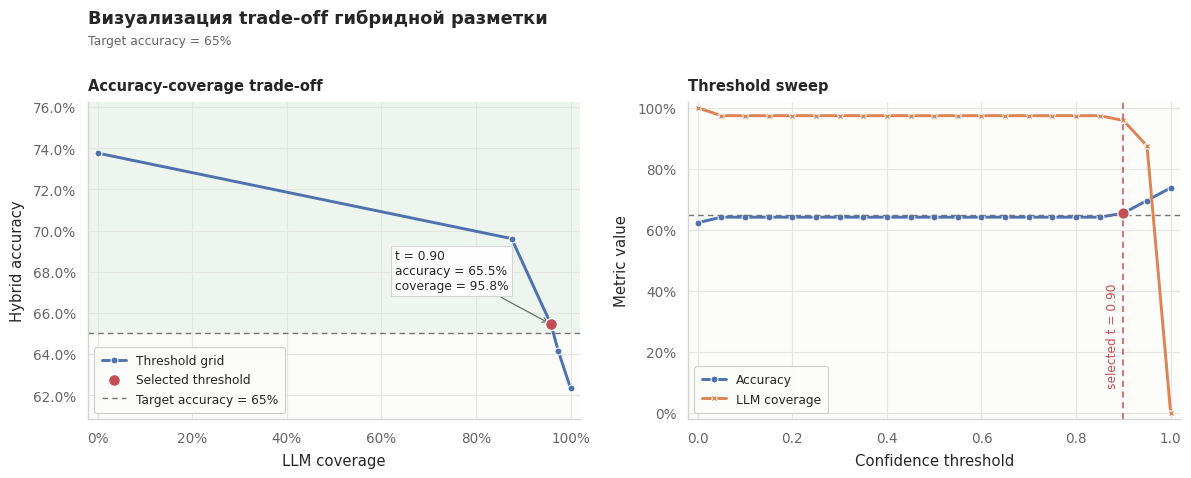

In [43]:
# да, заморочился с визуализацией, занесло )

from matplotlib.ticker import PercentFormatter

plot_df = pd.DataFrame(
    hybrid_threshold_results.sort("coverage").to_dicts()
)
threshold_df = pd.DataFrame(
    hybrid_threshold_results.sort("threshold").to_dicts()
)
metric_df = threshold_df.melt(
    id_vars="threshold",
    value_vars=["accuracy", "coverage"],
    var_name="metric",
    value_name="value",
)
metric_df["metric"] = metric_df["metric"].map(
    {"accuracy": "Accuracy", "coverage": "LLM coverage"}
)

palette = sns.color_palette("deep")
colors = {
    "accuracy": palette[0],
    "coverage": palette[1],
    "target": "#737373",
    "selected": palette[3],
    "zone": palette[2],
    "text": "#262626",
    "muted": "#666666",
    "grid": "#E5E5E5",
    "border": "#D4D4D4",
}
metric_palette = {
    "Accuracy": colors["accuracy"],
    "LLM coverage": colors["coverage"],
}
selected_note = chr(10).join(
    [
        f"t = {best_hybrid_threshold:.2f}",
        f"accuracy = {best_hybrid_accuracy:.1%}",
        f"coverage = {best_hybrid_coverage:.1%}",
    ]
)

acc_min = min(plot_df["accuracy"].min(), accuracy_target, best_hybrid_accuracy)
acc_max = max(plot_df["accuracy"].max(), accuracy_target, best_hybrid_accuracy)
ymin = max(0.0, acc_min - 0.015)
ymax = min(1.0, acc_max + 0.025)

rc = {
    "font.family": "DejaVu Sans",
    "figure.facecolor": "white",
    "axes.facecolor": "#FCFCFB",
    "axes.edgecolor": colors["border"],
    "axes.labelcolor": colors["text"],
    "axes.titlecolor": colors["text"],
    "xtick.color": colors["muted"],
    "ytick.color": colors["muted"],
    "text.color": colors["text"],
    "grid.color": colors["grid"],
    "grid.linewidth": 0.8,
    "grid.alpha": 1.0,
    "legend.frameon": True,
    "legend.fancybox": False,
    "legend.edgecolor": colors["border"],
    "legend.facecolor": "white",
}

with sns.axes_style("whitegrid", rc=rc), sns.plotting_context("paper", font_scale=1.12):
    fig = plt.figure(figsize=(12, 5), facecolor="white")
    grid = fig.add_gridspec(
        1,
        2,
        left=0.075,
        right=0.985,
        bottom=0.145,
        top=0.78,
        wspace=0.22,
    )
    axes = [fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1])]

    ax = axes[0]
    ax.axhspan(
        accuracy_target,
        1.0,
        color=colors["zone"],
        alpha=0.08,
        zorder=0,
    )
    sns.lineplot(
        data=plot_df,
        x="coverage",
        y="accuracy",
        marker="o",
        markersize=5,
        linewidth=2.1,
        color=colors["accuracy"],
        ax=ax,
        label="Threshold grid",
    )
    sns.scatterplot(
        x=[best_hybrid_coverage],
        y=[best_hybrid_accuracy],
        s=74,
        color=colors["selected"],
        edgecolor="white",
        linewidth=1.0,
        ax=ax,
        zorder=5,
        label="Selected threshold",
    )
    ax.axhline(
        accuracy_target,
        color=colors["target"],
        linestyle=(0, (4, 3)),
        linewidth=1.0,
        label=f"Target accuracy = {accuracy_target:.0%}",
    )
    ax.annotate(
        selected_note,
        xy=(best_hybrid_coverage, best_hybrid_accuracy),
        xytext=(best_hybrid_coverage - 0.33, best_hybrid_accuracy + 0.017),
        arrowprops={
            "arrowstyle": "->",
            "color": colors["muted"],
            "linewidth": 0.85,
        },
        bbox={
            "boxstyle": "square,pad=0.28",
            "facecolor": "white",
            "edgecolor": colors["border"],
            "alpha": 0.96,
        },
        fontsize=8.8,
        color=colors["text"],
    )
    ax.set_title("Accuracy-coverage trade-off", loc="left", pad=8, fontsize=10.5, fontweight="semibold")
    ax.set_xlabel("LLM coverage", labelpad=6)
    ax.set_ylabel("Hybrid accuracy", labelpad=6)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(ymin, ymax)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(title=None, loc="lower left", fontsize=8.8, framealpha=0.96, borderpad=0.6)
    sns.despine(ax=ax)

    ax = axes[1]
    sns.lineplot(
        data=metric_df,
        x="threshold",
        y="value",
        hue="metric",
        style="metric",
        markers=True,
        dashes=False,
        markersize=5,
        linewidth=2.1,
        palette=metric_palette,
        ax=ax,
    )
    ax.axvline(
        best_hybrid_threshold,
        color=colors["selected"],
        linestyle=(0, (4, 3)),
        linewidth=1.1,
    )
    ax.axhline(
        accuracy_target,
        color=colors["target"],
        linestyle=(0, (4, 3)),
        linewidth=1.0,
    )
    sns.scatterplot(
        x=[best_hybrid_threshold],
        y=[best_hybrid_accuracy],
        s=70,
        color=colors["selected"],
        edgecolor="white",
        linewidth=1.0,
        ax=ax,
        zorder=5,
    )
    ax.text(
        best_hybrid_threshold - 0.036,
        0.08,
        f"selected t = {best_hybrid_threshold:.2f}",
        rotation=90,
        ha="left",
        va="bottom",
        color=colors["selected"],
        fontsize=8.8,
    )
    ax.set_title("Threshold sweep", loc="left", pad=8, fontsize=10.5, fontweight="semibold")
    ax.set_xlabel("Confidence threshold", labelpad=6)
    ax.set_ylabel("Metric value", labelpad=6)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(title=None, loc="lower left", fontsize=8.8, framealpha=0.96, borderpad=0.6)
    sns.despine(ax=ax)

    fig.text(
        0.075,
        0.965,
        "Визуализация trade-off гибридной разметки",
        ha="left",
        va="top",
        fontsize=12.8,
        fontweight="semibold",
        color=colors["text"],
    )
    fig.text(
        0.075,
        0.915,
        f"Target accuracy = {int(accuracy_target * 100)}%",
        ha="left",
        va="top",
        fontsize=8.9,
        color=colors["muted"],
    )
    plt.show()

#### 8.2.4. Сравнение схем разметки (2 балла)

1. Посчитайте и сравните:
   - accuracy только человека (`human_labels`),
   - accuracy только LLM (`pred_labels`),
   - лучшую точку гибрида.
2. Кратко (2–3 предложения) ответьте:
   - в чём преимущество гибридного подхода по сравнению с «чисто человек» и «чисто LLM»?
   - в каких кейсах такая схема human-in-the-loop может быть особенно полезна?


In [44]:
# ---- Ваш код здесь ----
human_only_accuracy = float(
    np.mean(np.asarray(human_labels, dtype=object) == np.asarray(true_labels, dtype=object))
)
llm_only_accuracy = float(
    np.mean(np.asarray(pred_labels, dtype=object) == np.asarray(true_labels, dtype=object))
)

scheme_comparison = pl.DataFrame(
    [
        {
            "scheme": "human_only",
            "threshold": None,
            "accuracy": human_only_accuracy,
            "llm_coverage": 0.0,
        },
        {
            "scheme": "llm_only",
            "threshold": 0.0,
            "accuracy": llm_only_accuracy,
            "llm_coverage": 1.0,
        },
        {
            "scheme": "best_hybrid",
            "threshold": best_hybrid_threshold,
            "accuracy": best_hybrid_accuracy,
            "llm_coverage": best_hybrid_coverage,
        },
    ],
    schema={
        "scheme": pl.Utf8,
        "threshold": pl.Float64,
        "accuracy": pl.Float64,
        "llm_coverage": pl.Float64,
    },
)

scheme_comparison

# ---- Конец кода ----

scheme,threshold,accuracy,llm_coverage
str,f64,f64,f64
"""human_only""",null,0.737662,0.0
"""llm_only""",0.0,0.623377,1.0
"""best_hybrid""",0.9,0.654545,0.958442


*Вывод: гибридный подход позволяет отдавать LLM только те объекты, где уверенность достаточно высока, а остальные оставлять человеку; так можно управлять компромиссом между качеством и долей автоматизации.*

## Итоги домашки

В этой работе мы посмотрели на разметку как на систему, где есть и люди, и LLM.

Главное, что нужно вынести:
- LLM можно использовать как разметчика (при этом важно следить за качеством ), можно улучшать промт за счет различных прдеставленных способов.
- Оценка **уверенности** по logprobs позволяет решать, где доверять модели, а где подключать человека.
- Гибридная схема human-in-the-loop часто лучше, чем «только крауд» или «только LLM»: мы разгружаем людей на простых примерах и сохраняем качество на сложных.
- Эти идеи масштабируются дальше: улучшение промптов, дообучение модели, active learning и более умные пайплайны разметки.
